# 0. 思路说明

为简化计算, 先考虑一个公司一个股东的情况, 有两个需要模拟的方面:

模拟公司经营情况(财务数据, 被合规处罚情况, )

模拟股东状态和动作(增持减持, 股东身份, )





# 1. 部分工具

In [75]:
import platform
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def setup_chinese_font():
    """
    自动设置matplotlib的中文字体，根据操作系统类型选择合适的字体
    """
    system = platform.system()
    
    if system == 'Windows':
        # Windows系统默认安装的中文字体
        font_family = ['Microsoft YaHei', 'SimHei']
        
    elif system == 'Darwin':  # macOS
        # macOS系统默认安装的中文字体
        font_family = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC']
        
    elif system == 'Linux':
        # Linux系统常见的中文字体
        font_family = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'SimHei']
    
    else:
        print(f"未知操作系统类型: {system}")
        return
    
    # 遍历字体列表，使用第一个可用的字体
    font_found = False
    for font in font_family:
        try:
            # 测试字体是否可用
            plt.rcParams['font.family'] = [font]
            plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
            
            # 创建一个测试图并立即关闭，验证字体是否有效
            fig = plt.figure()
            plt.text(0.5, 0.5, '测试中文字体')
            plt.close(fig)
            
            print(f"成功设置中文字体: {font}")
            font_found = True
            break
        except Exception as e:
            continue
    
    if not font_found:
        print(f"警告：在{system}系统上未找到可用的中文字体")
        print("请手动安装中文字体后重试")


# 使用示例
setup_chinese_font()

成功设置中文字体: Arial Unicode MS


## 1.1 可视化: 回购行为

In [76]:
import pandas as pd
import numpy as np # 尽管在此函数最终版本中未直接大量使用，但通常是数据处理好伙伴
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# from typing import Dict # 如果需要对内部变量进行类型提示，可以取消注释
# from datetime import timedelta # 此函数中未使用

def plot_repurchase_and_selling_timeline(df: pd.DataFrame):
    """
    完全防御式的可视化函数，处理任何数据缺失情况。
    (已修正累计出售绘图错误)
    (优化：确保回购和出售期间的 axvspan 不会因重复数据而过浓，从而更好地显示重叠)
    """
    # 1. 检查和准备数据
    required_base_cols = ['日期', '收盘价']
    if not all(col in df.columns for col in required_base_cols):
        print("关键错误：数据缺少 '日期' 或 '收盘价' 列。无法生成图表。")
        return

    df_plot = df.copy() # 使用副本进行操作

    if not pd.api.types.is_datetime64_any_dtype(df_plot['日期']):
        try:
            df_plot['日期'] = pd.to_datetime(df_plot['日期'])
        except Exception as e:
            print(f"关键错误：无法将 '日期' 列转换为 datetime 类型: {e}。无法生成图表。")
            return
    df_plot = df_plot.sort_values(by='日期').reset_index(drop=True)


    # 2. 确定可用数据维度和列名
    rep_plan_flag_col, rep_start_col, rep_end_col = '存在回购方案', '实施开始日', '实施截止日'
    rep_daily_qty_col, rep_cum_qty_col = '当日回购数量', '累计回购数量'
    sell_plan_flag_col, sell_start_col, sell_end_col = '存在出售计划', '出售开始日', '出售截止日'
    sell_daily_qty_col, sell_cum_qty_col = '当日出售数量', '累计出售数量'
    total_shares_col = '总股本'

    has_rep_span = all(c in df_plot.columns for c in [rep_plan_flag_col, rep_start_col, rep_end_col])
    has_rep_volume = rep_daily_qty_col in df_plot.columns
    has_rep_cum = rep_cum_qty_col in df_plot.columns

    has_sell_span = all(c in df_plot.columns for c in [sell_plan_flag_col, sell_start_col, sell_end_col])
    has_sell_volume = sell_daily_qty_col in df_plot.columns
    has_sell_cum = sell_cum_qty_col in df_plot.columns
    
    has_total_shares = total_shares_col in df_plot.columns

    show_volume_plot = has_rep_volume or has_sell_volume
    show_cumulative_plot = (has_rep_cum or has_sell_cum) and has_total_shares

    # 3. 配色方案
    color_cfg = {
        'repurchase': {'color': '#4B96E9', 'alpha': 0.2, 'bar_alpha': 0.7, 'line_lw': 2}, # Alpha略微调高
        'selling':    {'color': '#FF6B6B', 'alpha': 0.2, 'bar_alpha': 0.7, 'line_lw': 2}, # Alpha略微调高
        'price_line': '#2C3E50'
    }

    # 4. 创建图表布局
    n_subplots = 1
    height_ratios = [2.5] # 股价图高度比例
    if show_volume_plot:
        n_subplots += 1
        height_ratios.append(1.5) # 交易量图高度比例
    if show_cumulative_plot:
        n_subplots += 1
        height_ratios.append(1.5) # 累计比例图高度比例

    fig = plt.figure(figsize=(16, n_subplots * 2.5 + (n_subplots-1)*0.5 )) # 根据子图数量动态调整高度
    gs = fig.add_gridspec(n_subplots, 1, height_ratios=height_ratios, hspace=0.1 * n_subplots) # 调整hspace

    # 5. 绘制各子图
    ax1 = fig.add_subplot(gs[0])
    shared_x_ax = ax1 # 后续子图共享此X轴

    # 5.1 股价 & 期间标记
    ax1.plot(df_plot['日期'], df_plot['收盘价'], label='收盘价', color=color_cfg['price_line'], lw=1.5, zorder=5)
    ax1.set_ylabel('股价 (元)')
    main_legend_handles = [Line2D([0], [0], color=color_cfg['price_line'], lw=1.5, label='收盘价')]

    if has_rep_span:
        unique_periods = df_plot.loc[df_plot[rep_plan_flag_col] == True, [rep_start_col, rep_end_col]].copy()
        unique_periods[rep_start_col] = pd.to_datetime(unique_periods[rep_start_col], errors='coerce')
        unique_periods[rep_end_col] = pd.to_datetime(unique_periods[rep_end_col], errors='coerce')
        unique_periods = unique_periods.dropna().drop_duplicates()
        for _, row in unique_periods.iterrows():
            if row[rep_start_col] <= row[rep_end_col]: # 确保是有效期间
                ax1.axvspan(row[rep_start_col], row[rep_end_col],
                            facecolor=color_cfg['repurchase']['color'], alpha=color_cfg['repurchase']['alpha'], zorder=1)
        if not unique_periods.empty:
            main_legend_handles.append(Patch(facecolor=color_cfg['repurchase']['color'], alpha=color_cfg['repurchase']['alpha']*2, label='回购期间'))

    if has_sell_span:
        unique_periods = df_plot.loc[df_plot[sell_plan_flag_col] == True, [sell_start_col, sell_end_col]].copy()
        unique_periods[sell_start_col] = pd.to_datetime(unique_periods[sell_start_col], errors='coerce')
        unique_periods[sell_end_col] = pd.to_datetime(unique_periods[sell_end_col], errors='coerce')
        unique_periods = unique_periods.dropna().drop_duplicates()
        for _, row in unique_periods.iterrows():
            if row[sell_start_col] <= row[sell_end_col]: # 确保是有效期间
                ax1.axvspan(row[sell_start_col], row[sell_end_col],
                            facecolor=color_cfg['selling']['color'], alpha=color_cfg['selling']['alpha'], zorder=1)
        if not unique_periods.empty:
            main_legend_handles.append(Patch(facecolor=color_cfg['selling']['color'], alpha=color_cfg['selling']['alpha']*2, label='出售期间'))
    
    ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    # 5.2 交易量图
    ax2 = None
    if show_volume_plot:
        ax_idx = fig.axes.index(shared_x_ax) + 1 # Find current index and add 1
        ax2 = fig.add_subplot(gs[ax_idx], sharex=shared_x_ax)
        if has_rep_volume:
            qty = pd.to_numeric(df_plot.get(rep_daily_qty_col, 0), errors='coerce').fillna(0)
            ax2.bar(df_plot['日期'][qty != 0], (qty / 10000)[qty != 0], width=1.0,
                    alpha=color_cfg['repurchase']['bar_alpha'], color=color_cfg['repurchase']['color'], label='当日回购(万股)')
        if has_sell_volume:
            qty = pd.to_numeric(df_plot.get(sell_daily_qty_col, 0), errors='coerce').fillna(0)
            ax2.bar(df_plot['日期'][qty != 0], (-qty / 10000)[qty != 0], width=1.0, # 负值表示出售
                    alpha=color_cfg['selling']['bar_alpha'], color=color_cfg['selling']['color'], label='当日出售(万股)')
        ax2.axhline(0, color='gray', lw=0.5)
        ax2.set_ylabel('当日交易量 (万股)')
        ax2.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
        if ax2.has_data(): ax2.legend(loc='upper left', fontsize='small', frameon=False)
        plt.setp(shared_x_ax.get_xticklabels(), visible=False) # 隐藏上一个X轴标签
        shared_x_ax = ax2 # 更新共享轴为当前轴

    # 5.3 累计比例图
    ax3 = None
    if show_cumulative_plot:
        ax_idx = fig.axes.index(shared_x_ax) + 1
        ax3 = fig.add_subplot(gs[ax_idx], sharex=shared_x_ax) # 注意这里共享的是ax1的X轴
        
        initial_ts_val = 0
        if not df_plot[total_shares_col].empty:
            valid_ts = pd.to_numeric(df_plot[total_shares_col], errors='coerce').dropna()
            if not valid_ts.empty: initial_ts_val = valid_ts.iloc[0]
        if initial_ts_val == 0:
            print("警告：初始总股本为0或无效，累计比例图无法准确计算。")
            initial_ts_val = 1 # 避免除零，但绘图无意义

        if has_rep_cum:
            qty = pd.to_numeric(df_plot.get(rep_cum_qty_col, 0), errors='coerce').fillna(0)
            ratio = qty / initial_ts_val
            ax3.plot(df_plot['日期'], ratio, color=color_cfg['repurchase']['color'], lw=color_cfg['repurchase']['line_lw'], label='累计回购比例')
        if has_sell_cum:
            qty = pd.to_numeric(df_plot.get(sell_cum_qty_col, 0), errors='coerce').fillna(0)
            ratio = qty / initial_ts_val
            ax3.plot(df_plot['日期'], ratio, color=color_cfg['selling']['color'], lw=color_cfg['selling']['line_lw'], label='累计出售比例')
        
        ax3.set_ylabel('累计占初始股本比例')
        ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
        ax3.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
        if ax3.has_data(): ax3.legend(loc='upper left', fontsize='small', frameon=False)
        plt.setp(shared_x_ax.get_xticklabels(), visible=False) # 隐藏上一个X轴标签
        # shared_x_ax = ax3 # No more plots below this usually

    # 6. 图表总体装饰
    # 主图例（股价图上方）
    if main_legend_handles:
        # 动态调整图例位置，避免与标题重叠太多
        legend_y_anchor = 1.05 + (0.06 * n_subplots) # 基础偏移 + 随子图数量增加的偏移
        ax1.legend(handles=main_legend_handles, loc='lower center', 
                   bbox_to_anchor=(0.5, legend_y_anchor),
                   ncol=min(len(main_legend_handles), 4), fontsize='medium', frameon=False)

    # X轴日期格式
    bottom_ax = fig.axes[-1]
    bottom_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    bottom_ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=12))
    plt.setp(bottom_ax.get_xticklabels(), rotation=30, ha='right')
    bottom_ax.set_xlabel('日期', fontsize='medium')

    # 主标题
    title_parts = ['股价走势']
    sub_titles = []
    if has_rep_span or has_rep_volume or has_rep_cum : sub_titles.append('回购')
    if has_sell_span or has_sell_volume or has_sell_cum: sub_titles.append('出售')
    
    if sub_titles:
        title_parts.append(f"及{'与'.join(sub_titles)}情况")
    fig.suptitle(' '.join(title_parts), fontsize=18, y=0.98 ) # 调整y使其在图例上方

    # 调整整体布局以适应标题和图例
    top_margin = 0.98 - (0.03 * n_subplots) - (0.02 * (len(main_legend_handles)//5 +1)) # 估算图例高度影响
    fig.tight_layout(rect=[0.02, 0.03, 0.98, top_margin]) 
    
    plt.show()

## 1.2 可视化: 财务和交易数据

In [77]:
import matplotlib.pyplot as plt

def draw_financial_and_treading(combined_company_info):

    combined_company_info = combined_company_info.copy()


    # 创建图表
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # 绘制上面的子图
    # 绘制收盘价和收盘价减每股净资产的折线图
    ax1.plot(combined_company_info['日期'], combined_company_info['收盘价'], label='收盘价', color='blue')
    ax1.plot(combined_company_info['日期'], combined_company_info['收盘价减每股净资产'], label='收盘价减每股净资产', color='green', alpha=0.3)

    # 创建右侧的坐标轴用于绘制日收益率
    ax1_2 = ax1.twinx()
    ax1_2.bar(combined_company_info['日期'], combined_company_info['日收益率'], color='gray', alpha=0.3, label='日收益率')
    ax1_2.set_ylabel('日收益率', color='gray')
    ax1_2.tick_params(axis='y', labelcolor='gray')

    # 在收益率的坐标轴上添加增长率为0的横线
    ax1_2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    # 设置标签和图例
    ax1.set_ylabel('价格（元）')
    ax1.legend(loc='upper left')
    ax1_2.legend(loc='upper right')

    # 绘制下面的子图
    # 绘制净资产和净利润的折线图
    ax2.plot(combined_company_info['日期'], combined_company_info['净资产'], label='净资产', color='blue')
    ax2.plot(combined_company_info['日期'], combined_company_info['净利润'], label='净利润', color='green')

    # 创建右侧的坐标轴用于绘制净资产增长率和净利润增长率
    ax2_2 = ax2.twinx()
    width = 5  # 设置柱状图的宽度
    ax2_2.bar(combined_company_info['日期'], combined_company_info['净资产增长率'], width=width, alpha=0.1, color='blue', label='净资产增长率')
    ax2_2.bar(combined_company_info['日期'], combined_company_info['净利润增长率'], width=width, alpha=0.1, color='green', label='净利润增长率')
    ax2_2.set_ylabel('增长率', color='red')
    ax2_2.tick_params(axis='y', labelcolor='red')

    # 在增长率的坐标轴上添加增长率为0的横线
    ax2_2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    # 设置标签和图例
    ax2.set_xlabel('日期')
    ax2.set_ylabel('值')
    ax2.legend(loc='upper left')
    ax2_2.legend(loc='upper right')

    # 添加网格和横线
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.axhline(0, color='gray', linewidth=0.8)
    ax2.axhline(0, color='gray', linewidth=0.8)

    # 设置标题
    ax1.set_title('收盘价、收盘价减每股净资产及日收益率')
    ax2.set_title('净资产、净利润及其增长率')

    # 显示图表
    plt.tight_layout()
    plt.show()
    

# 生成模拟数据

## 单个公司单个股东情况

### 财务数据

In [78]:
import pandas as pd
import numpy as np

DEFAULT_FINANCIAL_CONFIG = {
    # 时间范围配置
    "date_range": {
        "start_date": "2020-01-01",
        "end_date": "2024-12-31",
        "freq": "QE-DEC"  # 季度末日期
    },
    
    # 财务初始值配置
    "initial_values": {
        "net_assets": 180_000_000,    # 初始净资产
        "net_profit": 18_000_000,     # 初始净利润
        "total_shares": 40_000_000,   # 总股本
        "profit_adjustment": -17_000_000  # 净利润调整值
    },
    
    # 增长率配置
    "growth_rates": {
        "net_assets": {"mean": 0.03, "std": 0.09},
        "net_profit": {"mean": 0.05, "std": 0.4}
    },
    
    # 验证条件配置
    "validation": {
        "max_profit_asset_ratio": 0.3,          # 净利润/净资产最大比率
        "max_consecutive_loss_years": 3,        # 最大连续亏损年数
        "max_asset_growth_multiple": 5,         # 净资产最大增长倍数
        "min_loss_quarters": 2                  # 最小亏损季度数
    }
}

class FinancialDataGenerator:
    def __init__(self, config=None):
        self.config = config or DEFAULT_FINANCIAL_CONFIG
        self._process_config()
        
    def _process_config(self):
        """预处理配置参数"""
        # 生成季度日期序列
        date_cfg = self.config["date_range"]
        self.all_quarters = pd.date_range(
            start=date_cfg["start_date"],
            end=date_cfg["end_date"],
            freq=date_cfg["freq"]
        )
        self.num_quarters = len(self.all_quarters)
        
    def generate(self, max_retries=1000):
        """生成符合要求的财务数据"""
        for _ in range(max_retries):
            df = self._generate_base_data()
            df = self._calculate_derived_fields(df)
            if self._validate_data(df):
                return df
        raise ValueError("无法生成符合条件的数据，请调整配置参数")

    def _generate_base_data(self):
        """生成基础数据"""
        growth = self.config["growth_rates"]
        df = pd.DataFrame({
            "日期": self.all_quarters,
            "净资产增长率": np.random.normal(
                growth["net_assets"]["mean"],
                growth["net_assets"]["std"],
                self.num_quarters
            ),
            "净利润增长率": np.random.normal(
                growth["net_profit"]["mean"],
                growth["net_profit"]["std"],
                self.num_quarters
            )
        })
        return df

    def _calculate_derived_fields(self, df):
        """计算衍生字段"""
        init = self.config["initial_values"]
        
        # 计算累积增长率
        df["净资产"] = init["net_assets"] * (1 + df["净资产增长率"]).cumprod()
        df["净利润"] = init["net_profit"] * (1 + df["净利润增长率"]).cumprod()
        
        # 应用调整项
        df["净利润"] += init["profit_adjustment"]
        
        # 计算每股指标
        df["总股本"] = init["total_shares"]
        df["每股净资产"] = df["净资产"] / df["总股本"]
        df["每股净利润"] = df["净利润"] / df["总股本"]
        
        # 公告相关字段
        df["公告类型"] = df["日期"].apply(self._get_report_type)
        df["公告日期"] = df["日期"].apply(self._get_announcement_date)
        df["复权因子"] = 1
        
        return df

    def _get_report_type(self, date):
        """确定财务报告类型"""
        fmt_date = date.strftime("%m-%d")
        return {
            "03-31": "季报",
            "06-30": "半年报",
            "09-30": "季报",
            "12-31": "年报"
        }.get(fmt_date, None)

    def _get_announcement_date(self, date):
        """计算公告日期"""
        year = date.year
        month_day = date.strftime("%m-%d")
        
        if month_day == "06-30":
            return pd.Timestamp(f"{year}-08-27")  # 半年报的公告日期: 当年8月27日
        if month_day == "12-31":
            return pd.Timestamp(f"{year+1}-03-30") # 年报的公告日期: 次年3月30日
        if month_day == "03-31":
            return pd.Timestamp(f"{year}-04-30") # (一)季报的公告日期: 当年4月30日
        if month_day == "09-30":
            return pd.Timestamp(f"{year}-10-27") # (三)季报的公告日期: 当年10月27日
        return None

    def _validate_data(self, df):
        """验证数据是否符合业务规则"""
        val_cfg = self.config["validation"]
        
        # 条件1: 净利润/净资产比率限制
        ratio_condition = (df["净利润"] / df["净资产"] <= val_cfg["max_profit_asset_ratio"]).all()
        
        # 条件2: 连续亏损年数限制
        annual_profit = df.set_index("日期")["净利润"].resample("YE").sum()
        consecutive_loss = (annual_profit < 0).astype(int).groupby((annual_profit >= 0).cumsum()).cumsum()
        loss_condition = (consecutive_loss <= val_cfg["max_consecutive_loss_years"]).all()
        
        # 条件3: 净资产增长倍数限制
        asset_growth_condition = (df["净资产"].iloc[-1] / df["净资产"].iloc[0] <= val_cfg["max_asset_growth_multiple"])
        
        # 条件4: 最小亏损季度数
        loss_quarters_condition = (df["净利润"] < 0).sum() >= val_cfg["min_loss_quarters"]
        
        return all([ratio_condition, loss_condition, asset_growth_condition, loss_quarters_condition])


generator = FinancialDataGenerator()
# 生成数据
financial_data = generator.generate()

# 查看结果
financial_data

,日期,净资产增长率,净利润增长率,净资产,净利润,总股本,每股净资产,每股净利润,公告类型,公告日期,复权因子
0,2020-03-31,0.032030,-0.086629,1.857653e+08,-5.593158e+05,40000000,4.644133,-0.013983,季报,2020-04-30,1
1,2020-06-30,0.075916,-0.576481,1.998678e+08,-1.003705e+07,40000000,4.996696,-0.250926,半年报,2020-08-27,1
2,2020-09-30,-0.027292,-0.275851,1.944130e+08,-1.195779e+07,40000000,4.860324,-0.298945,季报,2020-10-27,1
3,2020-12-31,-0.026305,-0.029014,1.892989e+08,-1.210408e+07,40000000,4.732473,-0.302602,年报,2021-03-30,1
4,2021-03-31,0.045908,-0.033733,1.979892e+08,-1.226924e+07,40000000,4.949731,-0.306731,季报,2021-04-30,1
5,2021-06-30,-0.003720,0.126025,1.972528e+08,-1.167304e+07,40000000,4.931320,-0.291826,半年报,2021-08-27,1
6,2021-09-30,0.189987,0.662209,2.347282e+08,-8.145478e+06,40000000,5.868206,-0.203637,季报,2021-10-27,1
7,2021-12-31,-0.067977,0.196992,2.187722e+08,-6.401205e+06,40000000,5.469304,-0.160030,年报,2022-03-30,1
8,2022-03-31,-0.047744,0.403195,2.083271e+08,-2.127824e+06,40000000,5.208178,-0.053196,季报,2022-04-30,1
9,2022-06-30,0.325698,0.143270,2.761788e+08,2.913153e+03,40000000,6.904469,0.000073,半年报,2022-08-27,1


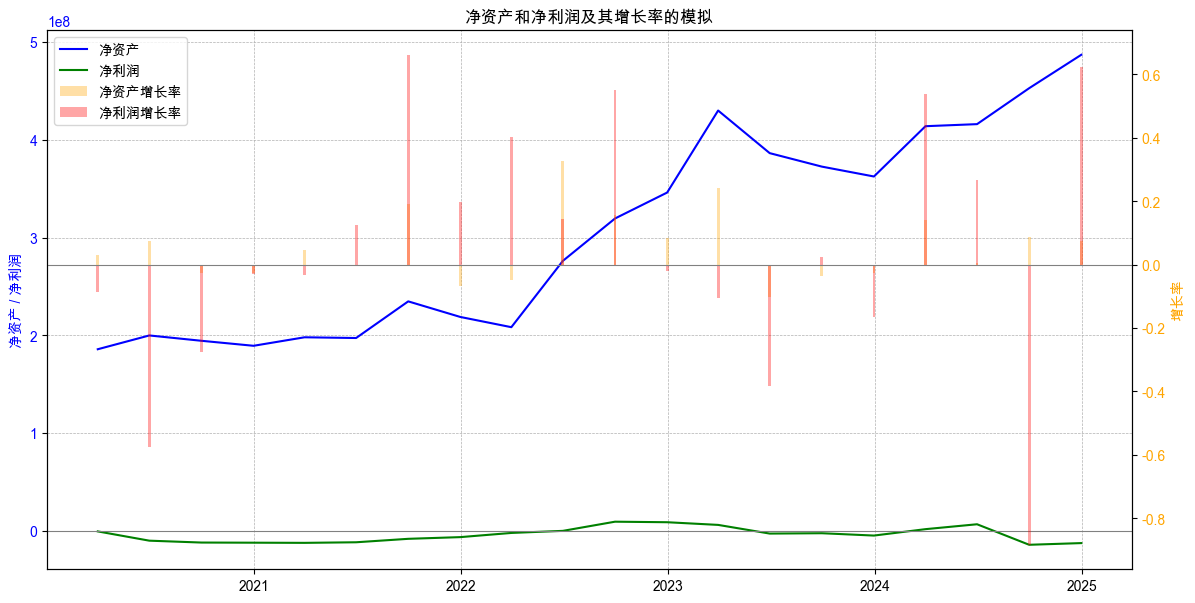

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.tseries.offsets import CustomBusinessDay


# 绘制图表
fig, ax1 = plt.subplots(figsize=(14, 7))

financial_df = financial_data

# 绘制净资产及净利润
ax2 = ax1.twinx()
ax1.plot(financial_df['日期'], financial_df['净资产'], color='blue', label='净资产')
ax1.plot(financial_df['日期'], financial_df['净利润'], color='green', label='净利润')
ax1.set_ylabel('净资产 / 净利润', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
lines_1, labels_1 = ax1.get_legend_handles_labels()  # 获取图例信息

# 绘制净资产增长率和净利润增长率的柱状图
width = 5  # 设置柱状图的宽度
ax2.bar(financial_df['日期'], financial_df['净资产增长率'], width=width, alpha=0.35, color='orange', label='净资产增长率')
ax2.bar(financial_df['日期'], financial_df['净利润增长率'], width=width, alpha=0.35, color='red', label='净利润增长率')
ax2.set_ylabel('增长率', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
lines_2, labels_2 = ax2.get_legend_handles_labels()  # 获取图例信息

# 合并和显示图例
lines = lines_1 + lines_2
labels = labels_1 + labels_2
ax1.legend(lines, labels, loc='upper left')

# 加横线
ax1.axhline(0, color='gray', linewidth=0.8)
ax2.axhline(0, color='gray', linewidth=0.8)  # 在增长率为0的位置添加横线

# 标题和网格
plt.title('净资产和净利润及其增长率的模拟')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

### 交易数据

In [80]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import CustomBusinessDay

DEFAULT_TRADING_CONFIG = {
    # 时间范围配置
    "date_range": {
        "start_date": "2020-01-01",
        "end_date": "2024-12-31"
    },
    
    # 市场参数配置
    "market_params": {
        "initial_price": 15.0,           # 初始股价
        "mean_return": 0.0002,           # 日均收益率
        "return_std": 0.02,              # 收益率标准差
        "trading_days_per_year": 242     # 年交易天数估算
    },
    
    # 假期配置（可根据实际情况调整）
    "holiday_rules": {
        "new_year_days": 1,              # 新年放假天数
        "spring_festival": {
            "start_month": 1, 
            "start_day": 24,
            "duration": 7
        },
        "qingming": {
            "start_month": 4,
            "start_day": 4,
            "duration": 3
        },
        "labor_day": {
            "start_month": 5,
            "start_day": 1,
            "duration": 5
        },
        "dragon_boat": {
            "start_month": 6,
            "start_day": 25,
            "duration": 3
        },
        "national_day": {
            "start_month": 10,
            "start_day": 1,
            "duration": 7
        }
    }
}

class TradingDataGenerator:
    def __init__(self, config=None):
        self.config = config or DEFAULT_TRADING_CONFIG
        self.trading_days = None
        self._prepare_calendar()
        
    def _prepare_calendar(self):
        """准备交易日历"""
        # 生成假期日期
        years = pd.date_range(
            start=self.config["date_range"]["start_date"],
            end=self.config["date_range"]["end_date"]
        ).year.unique()
        
        self.holidays = self._generate_holidays(years)
        
        # 创建交易日历
        trading_cal = CustomBusinessDay(holidays=self.holidays)
        self.trading_days = pd.date_range(
            start=self.config["date_range"]["start_date"],
            end=self.config["date_range"]["end_date"],
            freq=trading_cal
        )
    
    def _generate_holidays(self, years):
        """生成中国假期日期列表"""
        holidays = []
        for year in years:
            # 新年
            holidays.append(f"{year}-01-01")
            
            # 生成各假期
            h_rules = self.config["holiday_rules"]
            holidays += self._create_holiday_range(year, h_rules["spring_festival"])
            holidays += self._create_holiday_range(year, h_rules["qingming"])
            holidays += self._create_holiday_range(year, h_rules["labor_day"])
            holidays += self._create_holiday_range(year, h_rules["dragon_boat"])
            holidays += self._create_holiday_range(year, h_rules["national_day"])
        
        return pd.to_datetime(holidays).date.tolist()
    
    def _create_holiday_range(self, year, rule):
        """创建假期日期范围"""
        start_date = pd.Timestamp(year, rule["start_month"], rule["start_day"])
        return pd.date_range(
            start=start_date,
            periods=rule["duration"]
        ).strftime("%Y-%m-%d").tolist()
    
    def generate(self):
        """生成完整的交易数据"""
        params = self.config["market_params"]
        
        # 生成收益率序列
        returns = np.random.normal(
            params["mean_return"],
            params["return_std"],
            len(self.trading_days)
        )
        
        # 计算价格序列
        prices = params["initial_price"] * (1 + returns).cumprod()
        
        # 构建DataFrame
        df = pd.DataFrame({
            "日期": self.trading_days,
            "日收益率": returns,
            "收盘价": prices
        })
        
        # 添加前收盘价
        df["前收盘价"] = df["收盘价"].shift(1)

        # 添加上市日期
        # 过滤出在2021-01-01到2022-09-01之间的日期
        filtered_dates = df[(df['日期'] >= '2021-01-03') & (df['日期'] <= '2021-09-01')]['日期']
        # 从过滤后的日期中随机选择一个日期
        listing_date = filtered_dates.sample(n=1).iloc[0]
        df['上市日期'] = listing_date

        # 假设发行价格等于发行当日的收盘价
        df['发行价格'] = df.loc[df['日期'] == listing_date, '收盘价'].values[0]   
        
        # 将上市日期之前的数据替换为NaN
        df.loc[df['日期'] < listing_date, ['日收益率', '收盘价', '前收盘价', '发行价格']] = np.nan

        
        df['总股本'] = 40_000_000  # 假设总股本为4000万股
        df['复权因子'] = 1

        # 添加成交量 - 总股本的0.1%到10%之间的随机比例
        df['成交量'] = (df['总股本'] * np.random.uniform(0.001, 0.1, len(df))).astype(int)
        # 上市前的成交量设为0
        df.loc[df['日期'] < listing_date, '成交量'] = 0
        
        # 清理首行空值
        return df

    def plot_price_series(self, df):
        """绘制价格序列（可选方法）"""
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        plt.plot(df["日期"], df["收盘价"])
        plt.title("股票价格走势")
        plt.xlabel("日期")
        plt.ylabel("收盘价")
        plt.grid(True)
        plt.show()

trading_gen = TradingDataGenerator()
trading_df = trading_gen.generate()

trading_df

,日期,日收益率,收盘价,前收盘价,上市日期,发行价格,总股本,复权因子,成交量
0,2020-01-02,NaN,NaN,NaN,2021-08-25,NaN,40000000,1,0
1,2020-01-03,NaN,NaN,NaN,2021-08-25,NaN,40000000,1,0
2,2020-01-06,NaN,NaN,NaN,2021-08-25,NaN,40000000,1,0
3,2020-01-07,NaN,NaN,NaN,2021-08-25,NaN,40000000,1,0
4,2020-01-08,NaN,NaN,NaN,2021-08-25,NaN,40000000,1,0
...,...,...,...,...,...,...,...,...,...
1209,2024-12-25,-0.029397,8.372874,8.626470,2021-08-25,16.738215,40000000,1,212028
1210,2024-12-26,-0.005448,8.327258,8.372874,2021-08-25,16.738215,40000000,1,2205475
1211,2024-12-27,-0.008476,8.256679,8.327258,2021-08-25,16.738215,40000000,1,1062781
1212,2024-12-30,-0.010365,8.171098,8.256679,2021-08-25,16.738215,40000000,1,2905869


In [81]:
trading_df.columns

Index(['日期', '日收益率', '收盘价', '前收盘价', '上市日期', '发行价格', '总股本', '复权因子', '成交量'], dtype='object')

### 整合数据

In [82]:
import pandas as pd
import numpy as np

def merge_financial_trade_data(financial_df, tread_df):
    """
    合并财务数据和交易数据
    """
    # 转换日期列为 datetime 类型，并去除时区信息和时间部分
    financial_df['日期'] = pd.to_datetime(financial_df['日期']).dt.date
    financial_df['公告日期'] = pd.to_datetime(financial_df['公告日期']).dt.date
    tread_df['日期'] = pd.to_datetime(tread_df['日期']).dt.date

    # 读取 tread_df 的第一日和最后一日
    start_date = tread_df['日期'].min()
    end_date = tread_df['日期'].max()

    # 创建包含全部日期的序列
    all_dates = pd.date_range(start=start_date, end=end_date, freq='D').date
    combined_company_info = pd.DataFrame({'日期': all_dates})

    # 将 tread_df 的数据按照日期填入
    combined_company_info = combined_company_info.merge(tread_df, on='日期', how='left')

    # 遍历 combined_company_info，根据 '日期' 去匹配 financial_df
    for idx, row in combined_company_info.iterrows():
        current_date = row['日期']

        # 找到 financial_df 中 '公告日期' 早于当前日期的最晚的一行
        matching_rows = financial_df[financial_df['公告日期'] <= current_date]

        if not matching_rows.empty:
            latest_row = matching_rows.loc[matching_rows['公告日期'].idxmax()]

            # 删除 latest_row 中的 '日期' 列
            latest_row = latest_row.drop('日期')

            # 将这一行数据拼接到 combined_company_info
            for col in latest_row.index:
                if col not in combined_company_info.columns:
                    if '公告类型' in col:
                        combined_company_info[col] = ''
                    elif '日期' in col:
                        combined_company_info[col] = '' # pd.NaT
                    else:
                        combined_company_info[col] = np.nan  # 添加新列并初始化为 NaN
                combined_company_info.at[idx, col] = latest_row[col]

    # 将 <NA> 替换为 NaN
    combined_company_info = combined_company_info.replace({pd.NA: np.nan})

    # 筛选出交易日，并删除非交易日的行
    trade_dates = tread_df['日期']
    combined_company_info = combined_company_info[combined_company_info['日期'].isin(trade_dates)]

    # 计算每股净资产、每股净利润及其他列
    combined_company_info['每股净资产'] = combined_company_info['净资产'] / combined_company_info['总股本']
    combined_company_info['每股净利润'] = combined_company_info['净利润'] / combined_company_info['总股本']
    combined_company_info['收盘价减每股净资产'] = combined_company_info['收盘价'] - combined_company_info['每股净资产']
    combined_company_info['收盘价减每股净利润'] = combined_company_info['收盘价'] - combined_company_info['每股净利润']

    return combined_company_info



combined_company_info = merge_financial_trade_data(financial_data, trading_df)
combined_company_info = combined_company_info.dropna(subset=['净资产'])
combined_company_info

,日期,日收益率,收盘价,前收盘价,上市日期,发行价格,总股本,复权因子,成交量,净资产增长率,净利润增长率,净资产,净利润,每股净资产,每股净利润,公告类型,公告日期,收盘价减每股净资产,收盘价减每股净利润
119,2020-04-30,NaN,NaN,NaN,2021-08-25,NaN,40000000.0,1.0,0.0,0.032030,-0.086629,1.857653e+08,-5.593158e+05,4.644133,-0.013983,季报,2020-04-30,NaN,NaN
125,2020-05-06,NaN,NaN,NaN,2021-08-25,NaN,40000000.0,1.0,0.0,0.032030,-0.086629,1.857653e+08,-5.593158e+05,4.644133,-0.013983,季报,2020-04-30,NaN,NaN
126,2020-05-07,NaN,NaN,NaN,2021-08-25,NaN,40000000.0,1.0,0.0,0.032030,-0.086629,1.857653e+08,-5.593158e+05,4.644133,-0.013983,季报,2020-04-30,NaN,NaN
127,2020-05-08,NaN,NaN,NaN,2021-08-25,NaN,40000000.0,1.0,0.0,0.032030,-0.086629,1.857653e+08,-5.593158e+05,4.644133,-0.013983,季报,2020-04-30,NaN,NaN
130,2020-05-11,NaN,NaN,NaN,2021-08-25,NaN,40000000.0,1.0,0.0,0.032030,-0.086629,1.857653e+08,-5.593158e+05,4.644133,-0.013983,季报,2020-04-30,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819,2024-12-25,-0.029397,8.372874,8.626470,2021-08-25,16.738215,40000000.0,1.0,212028.0,0.088385,-0.883613,4.527762e+08,-1.423573e+07,11.319405,-0.355893,季报,2024-10-27,-2.946531,8.728767
1820,2024-12-26,-0.005448,8.327258,8.372874,2021-08-25,16.738215,40000000.0,1.0,2205475.0,0.088385,-0.883613,4.527762e+08,-1.423573e+07,11.319405,-0.355893,季报,2024-10-27,-2.992147,8.683152
1821,2024-12-27,-0.008476,8.256679,8.327258,2021-08-25,16.738215,40000000.0,1.0,1062781.0,0.088385,-0.883613,4.527762e+08,-1.423573e+07,11.319405,-0.355893,季报,2024-10-27,-3.062727,8.612572
1824,2024-12-30,-0.010365,8.171098,8.256679,2021-08-25,16.738215,40000000.0,1.0,2905869.0,0.088385,-0.883613,4.527762e+08,-1.423573e+07,11.319405,-0.355893,季报,2024-10-27,-3.148307,8.526992


In [83]:
100000 /40000000

0.0025

### 回购行为

In [84]:
import pandas as pd
import numpy as np
from typing import Dict

# ========================
# 新增配置参数
# ========================
REPO_CONFIG = {
    # 方案生成
    'prob_initiate_repurchase': 0.03,  # 无方案时每日发起概率
    'min_repurchase_days': 10,        # 最小回购实施天数
    'max_repurchase_days': 180,       # 最大回购实施天数
    
    # 方案特征概率
    'method_prob': [0.7, 0.3],       # 回购方式概率 [竞价, 要约]
    'purpose_prob': [0.5, 0.3, 0.2], # 用途概率 [维护价值, 股权激励, 转债]
    
    # 信息披露概率（每个要素独立概率）
    'disclosure_prob': 0.6,           # 各要素披露概率
    
    # 要约特征
    'offer_period_range': (30, 60),   # 要约期限天数范围
    'offer_price_lookback': 30,       # 要约价格参考前N日
    
    # 执行参数
    'prob_daily_execute': 0.4,        # 符合条件时每日执行概率
    'max_daily_ratio': 0.05,          # 单日最大回购比例（总股本）

    # 违法行为概率
    'prob_legal_violation': 0.005,  # 每日发生重大违法行为的概率
}

# ========================
# 工具函数
# ========================
def is_valid_trading_day(date: pd.Timestamp, df: pd.DataFrame) -> bool:
    """检查日期是否为交易日"""
    return date in df['日期'].values

def generate_offer_price(current_date: pd.Timestamp, df: pd.DataFrame, lookback: int) -> float:
    """生成要约价格（参考前lookback日的收盘价）"""
    try:
        # 获取当前日期的索引
        current_idx = df[df['日期'] == current_date].index[0]
        start_idx = max(0, current_idx - lookback)  # 确保不超出范围
        
        # 获取历史价格并过滤掉无效值
        historical_prices = df.iloc[start_idx:current_idx]['收盘价'].dropna()
        
        # 如果没有有效历史价格，则使用当前收盘价
        if len(historical_prices) == 0:
            return df.iloc[current_idx]['收盘价']
            
        return np.random.choice(historical_prices)
    except (IndexError, KeyError):
        # 如果出现任何错误，返回最近的有效收盘价
        valid_prices = df['收盘价'].dropna()
        if len(valid_prices) > 0:
            return valid_prices.iloc[-1]
        return 10.0  # 默认值，如果所有方法都失败

# ========================
# 核心处理函数
# ========================

def generate_repurchase_plan(prev_row: pd.Series, current_date: pd.Timestamp, df: pd.DataFrame) -> Dict:
    """
    生成回购计划（增强异常处理）
    返回包含计划要素的字典
    """
    try:
        # 新增收盘价非空检查
        current_close = df.loc[df['日期'] == current_date, '收盘价'].iloc[0]
        if pd.isna(current_close):
            return {}
    except IndexError:
        return {}

    # 原生成条件判断
    if prev_row['存在回购方案'] or np.random.rand() >= REPO_CONFIG['prob_initiate_repurchase']:
        return {}
    
    # 基础方案要素
    updates = {
        '存在回购方案': True,
        '决议通过日': current_date,
        '回购方式': np.random.choice(['竞价回购', '要约回购'], p=REPO_CONFIG['method_prob']),
        '回购用途': np.random.choice(['维护公司价值及股东权益所必需', 
                                  '股权激励或者员工持股计划', 
                                  '转换上市公司发行的可转换为股票的公司债券'], p=REPO_CONFIG['purpose_prob']),
    }
    
    # 随机生成披露要素
    if np.random.rand() < REPO_CONFIG['disclosure_prob']:
        updates['回购数量上限'] = np.random.randint(1, 5) * 0.01  # 总股本比例
    if np.random.rand() < REPO_CONFIG['disclosure_prob']:
        updates['回购数量下限'] = updates.get('回购数量上限', 0) * np.random.uniform(0.3, 0.7)
    if np.random.rand() < REPO_CONFIG['disclosure_prob']:
        updates['资金总额上限'] = prev_row['总股本'] * prev_row['收盘价'] * np.random.uniform(0.02, 0.1)
    if np.random.rand() < REPO_CONFIG['disclosure_prob']:
        updates['资金总额下限'] = updates.get('资金总额上限', 0) * np.random.uniform(0.3, 0.7)
    
    # 要约特殊处理（增强异常处理）
    if updates['回购方式'] == '要约回购':
        try:
            updates['要约期限'] = np.random.randint(*REPO_CONFIG['offer_period_range'])
            updates['要约价格'] = generate_offer_price(current_date, df, REPO_CONFIG['offer_price_lookback'])
        except:
            # 如果生成要约价格失败，改为竞价回购
            updates['回购方式'] = '竞价回购'
            updates.pop('要约期限', None)
            updates.pop('要约价格', None)
    
    # 计算实施期间
    start_date = current_date + pd.Timedelta(days=10)  # 假设决议后10日实施
    end_date = start_date + pd.Timedelta(
        days=np.random.randint(REPO_CONFIG['min_repurchase_days'], REPO_CONFIG['max_repurchase_days']))
    
    # 确保日期有效
    if is_valid_trading_day(start_date, df) and is_valid_trading_day(end_date, df):
        updates.update({
            '实施开始日': start_date,
            '实施截止日': end_date,
            '累计回购数量': 0,
            '已使用资金': 0.0
        })
        return updates
    return {}  # 日期无效时不生成

def execute_repurchase(prev_row: pd.Series, current_row: Dict, df: pd.DataFrame) -> Dict:
    """
    执行回购操作
    """
    if not prev_row['存在回购方案']:
        return current_row

    try:
        # 添加有效性检查
        if pd.isna(prev_row['收盘价']) or prev_row['收盘价'] <= 0:
            return current_row

        # 检查实施期间
        if not (prev_row['实施开始日'] <= current_row['日期'] <= prev_row['实施截止日']):
            return current_row

        # 价格生成（增强边界处理）
        if prev_row['回购方式'] == '竞价回购':
            base_price = prev_row['收盘价']
            lower = max(base_price * 0.8, 0.01)  # 防止出现0或负价格
            upper = base_price * 1.2
            price_range = (min(lower, upper), max(lower, upper))  # 确保范围有效
            current_row['申报价格'] = np.random.uniform(*price_range)
        else:
            # 要约价格生成增加边界保护
            try:
                current_row['申报价格'] = generate_offer_price(
                    current_row['日期'], 
                    df, 
                    REPO_CONFIG['offer_price_lookback']
                )
            except IndexError:
                current_row['申报价格'] = prev_row['收盘价']

        # 执行判断（增加资金上限检查）
        if (np.random.rand() < REPO_CONFIG['prob_daily_execute']) and pd.notna(prev_row.get('资金总额上限')):

            # 计算最大可回购量
            max_by_ratio = REPO_CONFIG['max_daily_ratio'] * prev_row['总股本']
            max_by_fund = (prev_row['资金总额上限'] - prev_row['已使用资金']) / current_row['申报价格']
            max_shares = min(max_by_ratio, max_by_fund)
            
            if max_shares > 0:
                execute_ratio = np.random.uniform(0.1, 0.5) * max_shares
                current_row['当日回购数量'] = execute_ratio
                current_row['累计回购数量'] = prev_row['累计回购数量'] + execute_ratio
                current_row['已使用资金'] = prev_row['已使用资金'] + execute_ratio * current_row['申报价格']
    
    except Exception as e:
        print(f"执行回购时出错 @ {current_row['日期']}: {str(e)}")
    
    return current_row

def check_and_reset_repurchase_plan(prev_row: pd.Series, current_row: Dict) -> Dict:
    """
    检查并重置已完成的回购计划
    """
    if not prev_row['存在回购方案']:
        return current_row
    
    # 检查是否超过截止日
    if current_row['日期'] > prev_row['实施截止日']:
        # 重置所有回购相关字段
        current_row.update({
            '存在回购方案': False,
            '决议通过日': pd.NaT,
            '实施开始日': pd.NaT,
            '实施截止日': pd.NaT,
            '回购方式': pd.NA,
            '回购用途': pd.NA,
            '回购数量上限': np.nan,
            '回购数量下限': np.nan,
            '资金总额上限': np.nan,
            '资金总额下限': np.nan,
            '要约期限': np.nan,
            '要约价格': np.nan,
            '申报价格': np.nan,
            '当日回购数量': 0.0,
            '累计回购数量': 0.0,
            '已使用资金': 0.0
        })
    
    return current_row

# ========================
# 主处理流程增强
# ========================
def main_simulation_repurchase(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # 初始化回购相关列
    repo_columns = {
        '公司法律情况':'',
        '存在回购方案': False,
        '决议通过日': pd.NaT,
        '实施开始日': pd.NaT,
        '实施截止日': pd.NaT,
        '回购方式': pd.NA,
        '回购用途': pd.NA,
        '回购数量上限': np.nan,
        '回购数量下限': np.nan,
        '资金总额上限': np.nan,
        '资金总额下限': np.nan,
        '要约期限': np.nan,
        '要约价格': np.nan,
        '申报价格': np.nan,
        '当日回购数量': 0.0,
        '累计回购数量': 0.0,
        '已使用资金': 0.0
    }
    for col, default in repo_columns.items():
        df[col] = default
    
    for i in range(1, len(df)):
        prev = df.iloc[i-1]
        current_row = df.iloc[i].copy()
        current_date = current_row['日期']
        
        # 继承方案状态
        current_row.update({k: prev[k] for k in repo_columns.keys()})

        # 检查并处理违法行为（新增）
        if np.random.rand() < REPO_CONFIG['prob_legal_violation']:
            current_row['公司法律情况'] = '发生重大违法行为'
        
        # 检查并重置已完成的回购计划
        current_row = check_and_reset_repurchase_plan(prev, current_row)
        
        # 生成新方案（仅在无方案时）
        if not current_row['存在回购方案'] and ((current_row['日期']- current_row['上市日期']).days >= 70):
            plan_updates = generate_repurchase_plan(prev, current_date, df)
            current_row.update(plan_updates)
        
        # 执行回购
        current_row = execute_repurchase(prev, current_row, df)
        
        # 更新总股本（示例逻辑）
        current_row['总股本'] = prev['总股本'] - current_row['当日回购数量']
        
        df.iloc[i] = current_row
    
    # 修正列顺序处理
    base_columns = [
        '日期', '收盘价', '总股本', '公司法律情况',
        '存在回购方案', '决议通过日', '实施开始日', '实施截止日',
        '回购方式', '回购用途', '回购数量上限', '回购数量下限',
        '资金总额上限', '资金总额下限', '要约期限', '要约价格',
        '申报价格', '当日回购数量', '累计回购数量', '已使用资金'
    ]
    
    # 获取其他列并去重
    other_columns = [col for col in df.columns if col not in base_columns]
    
    # 合并列顺序
    ordered_columns = base_columns + other_columns
    
    return df[ordered_columns]

In [85]:
generator = FinancialDataGenerator()
financial_data = generator.generate()

trading_gen = TradingDataGenerator()
trading_df = trading_gen.generate()

combined_company_info = merge_financial_trade_data(financial_data, trading_df)

combined_company_info_copy = combined_company_info.copy()
combined_company_info_copy['日期'] = pd.to_datetime(combined_company_info_copy['日期'])
# 运行模拟
one_company_df = main_simulation_repurchase(combined_company_info_copy)

# draw_financial_and_treading(combined_company_info)
# # plot_timeline(one_company_df)

### 出售回购股份行为

In [86]:
import pandas as pd
import numpy as np
from typing import Dict # 保持引入，良好实践
from datetime import timedelta # 保持引入

# ========================
# 配置参数 (与上次一致)
# ========================
CONFIG = {
    'prob_daily_sell': 0.5, 'min_planned_sell_ratio': 0.50, 'max_planned_sell_ratio': 1.50,
    'max_daily_sell_ratio': 0.15, 'prob_disclosure': 0.6, 'min_sell_period': 10,
    'max_sell_period': 90, 'min_daily_actual_sell_fraction': 0.20,
    'max_daily_actual_sell_fraction': 0.70, 'min_disclosure_advance_days': 10,
    'max_disclosure_advance_days': 30, 'float_tolerance': 1e-9,
    'price_lower_bound_ratio': 0.9, 'price_upper_bound_ratio': 1.1, 'min_price': 0.01
}

def generate_sell_plan(prev_row: pd.Series, current_row: Dict, df: pd.DataFrame) -> Dict:
    """
    生成股票出售计划的参数。
    (修改：不再设置 '存在出售计划' 标志，仅定义计划参数)
    """
    available_shares = prev_row['累计回购数量'] - prev_row['累计出售数量']
    shares_available = available_shares > CONFIG['float_tolerance']
    
    # 条件：有股份可卖 且 前一天不存在有效的出售计划 (prev_row['存在出售计划'] is not True 会正确处理False和NA)
    # 这个条件是用来决定是否 *尝试* 创建一个新计划结构。
    # 如果 prev_row['存在出售计划'] 是 True，意味着昨天有一个计划，simulate_share_selling的主循环会先评估那个计划。
    if shares_available and (prev_row['存在出售计划'] is not True):
        sell_period = np.random.randint(
            CONFIG['min_sell_period'],
            CONFIG['max_sell_period'] + 1
        )
        
        sell_start_date = current_row['日期'] 

        disclosure_advance_days = np.random.randint(
            CONFIG['min_disclosure_advance_days'],
            CONFIG['max_disclosure_advance_days'] + 1
        )
        sell_disclosure_date = sell_start_date - timedelta(days=disclosure_advance_days)
        
        repurchase_ratio = prev_row['累计回购数量'] / prev_row['总股本'] if prev_row['总股本'] > 0 else 0
        planned_ratio = np.random.uniform(
            CONFIG['min_planned_sell_ratio'],
            CONFIG['max_planned_sell_ratio']
        ) * repurchase_ratio
        
        current_row.update({
            '出售计划披露日': sell_disclosure_date,
            '出售开始日': sell_start_date,
            '出售截止日': sell_start_date + timedelta(days=sell_period),
            '拟出售比例': round(planned_ratio, 4),
            '拟出售数量': round(planned_ratio * prev_row['总股本'], 2),
            # --- 重要：不再在此处设置 '存在出售计划' ---
            '累计出售数量': 0.0, # 新计划的累计从0开始
            '累计出售比例': 0.0,
        })
    return current_row # 返回包含新计划参数（如果生成了）或原样（如果未生成）的current_row

def execute_sell_plan(prev_row: pd.Series, current_row: Dict, df: pd.DataFrame) -> Dict:
    """
    执行当日出售操作 (与上一版本相同)
    """
    current_plan_cumulative_sold_start_of_day = current_row['累计出售数量']
    current_row.update({
        '当日出售价格': 0.0, '当日出售比例': 0.0, '当日出售数量': 0.0,
        '披露出售进展': pd.NA # 使用pd.NA以便与nullable boolean兼容
    })

    try:
        global_repo_shares_remaining_check = max(0.0, prev_row['累计回购数量'] - prev_row['累计出售数量'])
        planned_remaining_in_current_plan = max(0.0, current_row['拟出售数量'] - current_plan_cumulative_sold_start_of_day)
        
        if global_repo_shares_remaining_check > CONFIG['float_tolerance'] and \
           planned_remaining_in_current_plan > CONFIG['float_tolerance'] and \
           np.random.rand() < CONFIG['prob_daily_sell']:
            
            close_price = current_row['收盘价']
            total_shares = current_row['总股本']
            sell_price = np.random.uniform(
                max(CONFIG['min_price'], close_price * CONFIG['price_lower_bound_ratio']),
                close_price * CONFIG['price_upper_bound_ratio']
            )
            daily_max_sell_qty_for_plan = CONFIG['max_daily_sell_ratio'] * current_row['拟出售数量']
            max_sell_today = min(daily_max_sell_qty_for_plan, planned_remaining_in_current_plan, global_repo_shares_remaining_check)
            
            sell_qty = 0.0
            if max_sell_today > CONFIG['float_tolerance']:
                min_frac, max_frac = CONFIG['min_daily_actual_sell_fraction'], CONFIG['max_daily_actual_sell_fraction']
                actual_sell_fraction = np.random.uniform(min_frac, max_frac) if min_frac < max_frac else min_frac
                sell_qty = max(0.0, min(max_sell_today, actual_sell_fraction * max_sell_today))
            
            if sell_qty > CONFIG['float_tolerance']:
                sell_ratio_today = sell_qty / total_shares if total_shares > 0 else 0.0
                new_plan_cumulative_sold = current_plan_cumulative_sold_start_of_day + sell_qty
                new_plan_cumulative_ratio = new_plan_cumulative_sold / total_shares if total_shares > 0 else 0.0
                current_row.update({
                    '当日出售数量': sell_qty, '当日出售价格': round(sell_price, 2),
                    '当日出售比例': round(sell_ratio_today, 6), '累计出售数量': new_plan_cumulative_sold,
                    '累计出售比例': round(new_plan_cumulative_ratio, 4),
                    '披露出售进展': np.random.rand() < CONFIG['prob_disclosure'] if new_plan_cumulative_ratio > 0 else pd.NA
                })
    except Exception as e:
        date_str = current_row.get('日期', pd.Timestamp('today')).strftime('%Y-%m-%d')
        print(f"执行异常 @ {date_str}: {str(e)}")

    plan_quota_met = (current_row['拟出售数量'] > CONFIG['float_tolerance'] and \
                      current_row['累计出售数量'] >= current_row['拟出售数量'] - CONFIG['float_tolerance'])
    plan_sold_all_repo_shares = current_row['累计出售数量'] >= prev_row['累计回购数量'] - CONFIG['float_tolerance']

    if plan_quota_met or plan_sold_all_repo_shares:
        current_row['存在出售计划'] = pd.NA # 标记计划结束，使用pd.NA以便与nullable boolean兼容
    return current_row


def simulate_share_selling(df_with_repurchase: pd.DataFrame) -> pd.DataFrame:
    """
    主函数：模拟股票出售流程
    (修改：'存在出售计划' 从披露日开始为True)
    """
    required_cols = ['日期', '收盘价', '总股本', '累计回购数量', '实施截止日']
    missing = [col for col in required_cols if col not in df_with_repurchase.columns]
    if missing: raise ValueError(f"缺少必要字段: {missing}")

    df = df_with_repurchase.copy()
    df['日期'] = pd.to_datetime(df['日期'])
    df = df.sort_values('日期').reset_index(drop=True)

    state_cols_config = {
        '出售计划披露日': ('datetime64[ns]', pd.NaT), 
        '存在出售计划': ('boolean', pd.NA), # Default to NA for nullable boolean
        '出售开始日': ('datetime64[ns]', pd.NaT),
        '出售截止日': ('datetime64[ns]', pd.NaT),
        '拟出售比例': ('float64', 0.0), '拟出售数量': ('float64', 0.0),
        '当日出售价格': ('float64', 0.0), '当日出售比例': ('float64', 0.0),
        '当日出售数量': ('float64', 0.0), '累计出售数量': ('float64', 0.0),
        '累计出售比例': ('float64', 0.0), '披露出售进展': ('boolean', pd.NA)
    }

    for col, (dtype, default) in state_cols_config.items():
        if col not in df.columns:
            df[col] = default if dtype != 'boolean' else pd.Series([default]*len(df), dtype='boolean')
        try:
            if dtype == 'datetime64[ns]': df[col] = pd.to_datetime(df[col], errors='coerce')
            elif dtype == 'boolean':
                df[col] = df[col].map({True: True, 1: True, 'True': True, 'TRUE': True, 'true': True,
                                       False: False, 0: False, 'False': False, 'FALSE': False, 'false': False,
                                       # Explicitly map common string NAs if any, else they become NaT then NA
                                       'nan': pd.NA, 'NaN': pd.NA, 'NAN': pd.NA, '': pd.NA, None: pd.NA 
                                      }).astype('boolean')
                if col not in df_with_repurchase.columns: df[col] = df[col].fillna(default) # Fill NAs for new columns
            else: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(default).astype(dtype)
        except Exception as e: # Simplified error handling
            print(f"列 '{col}' 初始化警告: {e}. 将强制设为默认类型和值.")
            if dtype == 'boolean': df[col] = pd.Series([default]*len(df), dtype='boolean')
            elif dtype == 'datetime64[ns]': df[col] = pd.Series([default]*len(df), dtype='datetime64[ns]')
            else: df[col] = pd.Series([default]*len(df), dtype='float64')


    plan_details_cols_to_inherit = [
        '出售计划披露日', '存在出售计划', '出售开始日', '出售截止日', 
        '拟出售比例', '拟出售数量', '累计出售数量', '累计出售比例'
    ]

    for i in range(1, len(df)):
        try:
            prev = df.iloc[i-1]
            current_dict = df.iloc[i].to_dict() 
            
            # 1. 继承上一日的完整计划状态
            for col_name in plan_details_cols_to_inherit:
                current_dict[col_name] = prev[col_name]
            
            # 2. 初始化当日的交易数据
            current_dict['当日出售数量'] = 0.0; current_dict['当日出售价格'] = 0.0;
            current_dict['当日出售比例'] = 0.0; current_dict['披露出售进展'] = state_cols_config['披露出售进展'][1]

            # 3. 检查继承的计划是否已结束 (因到期或售罄)，如果结束则清理计划参数为尝试生成新计划做准备
            #    注意: prev['存在出售计划'] 可能已经是False/NA，这里要判断的是 prev 定义的那个 plan instance
            #    如果 prev['出售开始日'] 是有效的，说明昨天可能有一个 plan instance 的定义被继承了。
            if pd.notna(prev['出售开始日']): # 检查是否曾有一个计划定义被继承
                # 使用 prev 的状态来判断该计划是否应在 prev 日结束
                # '存在出售计划' 在 prev 日可能已被 execute_sell_plan 置为 False/NA
                prev_plan_ended_yesterday = pd.isna(prev['存在出售计划']) or not prev['存在出售计划']
                # 或者按日期判断是否在 prev 日或之前就到期了
                date_expired_on_or_before_prev = pd.notna(prev['出售截止日']) and prev['日期'] >= prev['出售截止日']
                
                if prev_plan_ended_yesterday or date_expired_on_or_before_prev:
                    # 如果继承的计划实际上在昨天或更早已经结束，则清理 current_dict 中的计划参数
                    current_dict['出售计划披露日'] = pd.NaT; current_dict['出售开始日'] = pd.NaT
                    current_dict['出售截止日'] = pd.NaT; current_dict['拟出售比例'] = 0.0
                    current_dict['拟出售数量'] = 0.0; current_dict['累计出售数量'] = 0.0
                    current_dict['累计出售比例'] = 0.0
                    # '存在出售计划' 将在下面根据新规则重新评估，所以这里不用特意设为False/NA

            # 4. 如果当前 current_dict 中没有有效的计划定义 (例如 '出售开始日' 为 NaT)，尝试生成新计划
            #    generate_sell_plan 基于 prev_row['存在出售计划'] 来决定是否生成。
            if pd.isna(current_dict['出售开始日']): 
                current_dict = generate_sell_plan(prev, current_dict, df)
                # generate_sell_plan 会填充新的计划参数（包括披露日、开始日等），累计出售为0
                # 但不设置 '存在出售计划'

            # 5. 根据 current_dict 中的计划参数，为“今天”动态设定 '存在出售计划' 标志
            today = current_dict['日期']
            disclosure_dt = current_dict.get('出售计划披露日')
            start_dt = current_dict.get('出售开始日') # 实际出售开始日
            end_dt = current_dict.get('出售截止日')
            quota = current_dict.get('拟出售数量', 0.0)
            cum_sold = current_dict.get('累计出售数量', 0.0)
            
            # 先设为默认的“不存在”状态
            current_dict['存在出售计划'] = state_cols_config['存在出售计划'][1] 

            if pd.notna(disclosure_dt) and pd.notna(start_dt) and pd.notna(end_dt) and quota > CONFIG['float_tolerance']:
                is_disclosed_for_today = today >= disclosure_dt
                is_within_plan_active_dates = today <= end_dt # 计划的整个生命周期从披露到截止
                is_quota_not_met = not (cum_sold >= quota - CONFIG['float_tolerance'])

                if is_disclosed_for_today and is_within_plan_active_dates and is_quota_not_met:
                    current_dict['存在出售计划'] = True
                else:
                    # 如果不满足上述条件，但plan结构还存在（例如披露日还未到，或已过截止日/售罄）
                    # 我们需要确保累计值被正确处理。
                    # 如果是因为 disclosure_dt > today 而 plan_exists = False，累计值应为0 (新计划已是0)
                    # 如果是因为 today > end_dt 或 quota_met，累计值应是最终值，但 plan_exists = False
                    # 并在下一次迭代的步骤3中被清理。
                    # 对于今天，如果 '存在出售计划' 被设为False，但仍有残留的累计值，应清零。
                    # (这主要针对 disclosure_dt > today 的情况，其他情况由步骤3处理次日清零)
                    if today < disclosure_dt and pd.notna(start_dt): # 明确的未来计划，累计应为0
                        current_dict['累计出售数量'] = 0.0
                        current_dict['累计出售比例'] = 0.0


            # 6. 如果“存在出售计划”且已到“出售开始日”，则执行实际出售
            plan_exists_today_final = current_dict['存在出售计划']
            if pd.isna(plan_exists_today_final): plan_exists_today_final = False

            if plan_exists_today_final and pd.notna(start_dt) and today >= start_dt:
                current_dict = execute_sell_plan(prev, current_dict, df)
                # execute_sell_plan 可能会因为售罄而将 current_dict['存在出售计划'] 置为 False/NA
                # 这会影响下一天迭代开始时的 prev['存在出售计划']

            # 7. 更新DataFrame
            for key, value in current_dict.items():
                df.loc[i, key] = value

        except Exception as e:
            date_str = df.loc[i, '日期'] if pd.notna(df.loc[i, '日期']) else f"行 {i}"
            if isinstance(date_str, pd.Timestamp): date_str = date_str.strftime('%Y-%m-%d')
            print(f"主循环处理失败 @ {date_str}: {str(e)}")
            import traceback; print(traceback.format_exc())
            continue
            
    for col, (dtype, default_val) in state_cols_config.items(): # Final type assertion
        if dtype == 'boolean': df[col] = df[col].astype('boolean')
            
    return df

In [87]:
def adjust_selling_plan(df):
    """
    根据日期是否在实施期间内调整'存在出售计划'列
    
    参数:
        df: pandas DataFrame, 包含'日期', '实施开始日', '实施截止日', '存在出售计划'列
    
    返回:
        调整后的 DataFrame
    """
    # 确保日期列都是datetime格式
    date_columns = ['日期', '实施开始日', '实施截止日']
    for col in date_columns:
        if df[col].dtype != 'datetime64[ns]':
            df[col] = pd.to_datetime(df[col])
    
    # 对每一行进行判断
    df['存在出售计划'] = df.apply(
        lambda row: True if (row['实施开始日'] <= row['日期'] <= row['实施截止日']) else False,
        axis=1
    )
    
    return df

In [88]:
one_company_df = adjust_selling_plan(simulate_share_selling(one_company_df))
one_company_df.columns

Index(['日期', '收盘价', '总股本', '公司法律情况', '存在回购方案', '决议通过日', '实施开始日', '实施截止日',
       '回购方式', '回购用途', '回购数量上限', '回购数量下限', '资金总额上限', '资金总额下限', '要约期限', '要约价格',
       '申报价格', '当日回购数量', '累计回购数量', '已使用资金', '日收益率', '前收盘价', '上市日期', '发行价格',
       '复权因子', '成交量', '净资产增长率', '净利润增长率', '净资产', '净利润', '每股净资产', '每股净利润',
       '公告类型', '公告日期', '收盘价减每股净资产', '收盘价减每股净利润', '出售计划披露日', '存在出售计划', '出售开始日',
       '出售截止日', '拟出售比例', '拟出售数量', '当日出售价格', '当日出售比例', '当日出售数量', '累计出售数量',
       '累计出售比例', '披露出售进展'],
      dtype='object')

In [89]:
['日期', '决议通过日', '实施开始日', '实施截止日', '上市日期', '公告日期', '出售开始日', '出售截止日']

['日期', '决议通过日', '实施开始日', '实施截止日', '上市日期', '公告日期', '出售开始日', '出售截止日']

In [90]:
one_company_df['存在出售计划'].sum()

np.int64(346)

/var/folders/0l/pjlf4pl90rx7ldkq7jx18ny00000gn/T/ipykernel_94535/3877428229.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0.03, 0.98, top_margin])


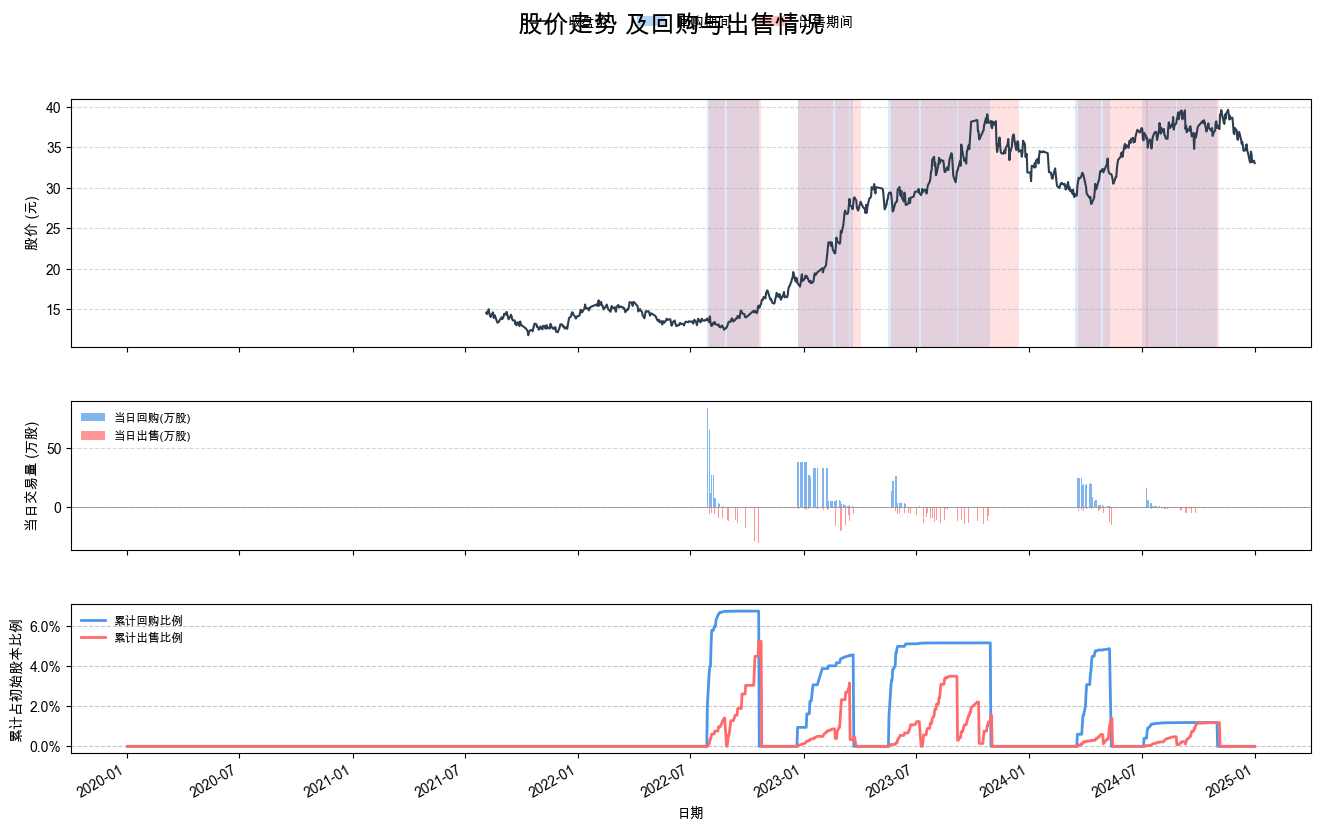

In [91]:

plot_repurchase_and_selling_timeline(one_company_df)


<Axes: >

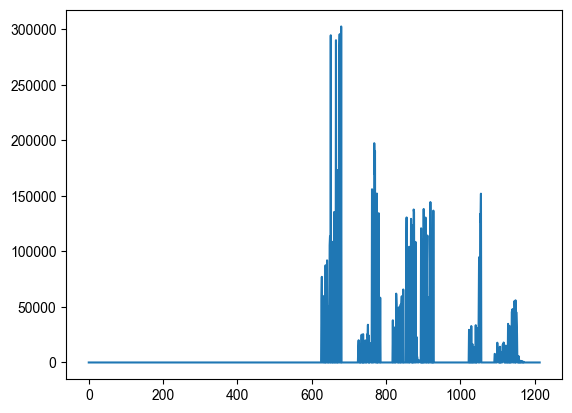

In [92]:
one_company_df['当日出售数量'].plot()

### 法律行为

In [42]:
import numpy as np
import pandas as pd

def add_legal_status(df, violation_prob=0.05):
    """
    向DataFrame添加公司法律情况列，小概率出现"重大违法行为"
    
    参数:
        df: pandas DataFrame
        violation_prob: float, 出现"重大违法行为"的概率，默认0.05 (5%)
    
    返回:
        添加了"公司法律情况"列的DataFrame
    """
    # 复制DataFrame以避免修改原始数据
    result_df = df.copy()
    
    # 生成随机布尔掩码，True的概率为violation_prob
    n_rows = len(df)
    violation_mask = np.random.random(n_rows) < violation_prob
    
    # 添加"公司法律情况"列，默认为空字符串
    result_df['公司法律情况'] = ''
    
    # 对符合掩码的行填入"重大违法行为"
    result_df.loc[violation_mask, '公司法律情况'] = '重大违法行为'
    
    return result_df

## 批量生成

In [43]:

# 财务数据
generator = FinancialDataGenerator()
financial_data = generator.generate()

# 交易数据
trading_gen = TradingDataGenerator()
trading_df = trading_gen.generate()

# 合并
combined_company_info = merge_financial_trade_data(financial_data, trading_df)
combined_company_info_copy = combined_company_info.copy()
combined_company_info_copy['日期'] = pd.to_datetime(combined_company_info_copy['日期'])

# 回购行为
one_company_df = main_simulation_repurchase(combined_company_info_copy)

# 出售回购的股份行为
one_company_df = adjust_selling_plan(simulate_share_selling(one_company_df))

# 违法行为
one_company_df = add_legal_status(one_company_df, violation_prob=0.005)


In [44]:
import random
from tqdm import tqdm

# 定义一些偏门的汉字
prefixes = ["曦", "昱", "沅", "淼", "珏", "琬", "瑾", "鸾", "翰", "裴", "霖", "钧", "铄", "骁", "颢", "麒", "筠", "珣", "芷", "蔚", "璟", "翊", "旻", "暄", "泓", "澜", "玥", "祎", "昀"]
suffixes = ["珺", "滢", "瀚", "骞", "琛", "煜", "瑄", "璨", "祺", "颉", "瀚", "霆", "翊", "琨", "璐", "璞", "琰", "璟", "琮", "琯", "瑾", "珹", "璋", "珵", "琮", "瑗", "璜", "琛", "璱", "玮"]
industries = ["股份", "科技", "实业", "集团", "控股", "电力", "化工", "物流", "医药", "地产", "机械", "农业", "传媒", "食品", "环保", "信息", "能源", "交通", "建筑", "生物"]

# First generate 50 company names using the provided code
company_names = []
for _ in range(50):
    prefix = random.choice(prefixes)
    suffix = random.choice(suffixes)
    industry = random.choice(industries)
    company_name = f"{prefix}{suffix}{industry}"
    company_names.append(company_name)

# Generate data for each company and combine
all_financial_data = []

for company in tqdm(company_names):
    # 财务数据
    generator = FinancialDataGenerator()
    financial_data = generator.generate()

    # 交易数据
    trading_gen = TradingDataGenerator()
    trading_df = trading_gen.generate()

    # 合并
    combined_company_info = merge_financial_trade_data(financial_data, trading_df)
    combined_company_info_copy = combined_company_info.copy()
    combined_company_info_copy['日期'] = pd.to_datetime(combined_company_info_copy['日期'])

    # 回购行为
    one_company_df = main_simulation_repurchase(combined_company_info_copy)

    # 出售回购的股份行为
    one_company_df = adjust_selling_plan(simulate_share_selling(one_company_df))

    # 违法行为
    one_company_df = add_legal_status(one_company_df, violation_prob=0.005)
    
    # Append to our list of all data
    one_company_df['公司简称'] = company
    all_financial_data.append(one_company_df)


# Combine all companies' data into one large DataFrame
combined_financial_data = pd.concat(all_financial_data, ignore_index=True)

# 确保所有日期列都转换为pandas的datetime格式
date_columns = ['日期', '决议通过日', '实施开始日', '实施截止日', '上市日期', '公告日期', '出售开始日', '出售截止日']

# 转换日期列
for col in date_columns:
    combined_financial_data[col] = pd.to_datetime(combined_financial_data[col])  # 对于无法解析的日期返回 NaT

combined_financial_data 

100%|██████████| 50/50 [03:31<00:00,  4.23s/it]


,日期,收盘价,总股本,公司法律情况,存在回购方案,决议通过日,实施开始日,实施截止日,回购方式,回购用途,...,出售截止日,拟出售比例,拟出售数量,当日出售价格,当日出售比例,当日出售数量,累计出售数量,累计出售比例,披露出售进展,公司简称
0,2020-01-02,NaN,4.000000e+07,,False,NaT,NaT,NaT,<NA>,<NA>,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,昀璞能源
1,2020-01-03,NaN,4.000000e+07,,False,NaT,NaT,NaT,None,None,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,昀璞能源
2,2020-01-06,NaN,4.000000e+07,,False,NaT,NaT,NaT,None,None,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,昀璞能源
3,2020-01-07,NaN,4.000000e+07,,False,NaT,NaT,NaT,None,None,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,昀璞能源
4,2020-01-08,NaN,4.000000e+07,,False,NaT,NaT,NaT,None,None,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,昀璞能源
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60695,2024-12-25,7.033894,2.857295e+07,,False,2023-10-17,2023-10-27,2024-03-28,竞价回购,转换上市公司发行的可转换为股票的公司债券,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,沅琮建筑
60696,2024-12-26,7.077646,2.857295e+07,,False,2023-10-17,2023-10-27,2024-03-28,竞价回购,转换上市公司发行的可转换为股票的公司债券,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,沅琮建筑
60697,2024-12-27,7.215469,2.857295e+07,,False,2023-10-17,2023-10-27,2024-03-28,竞价回购,转换上市公司发行的可转换为股票的公司债券,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,沅琮建筑
60698,2024-12-30,7.264917,2.857295e+07,,False,2023-10-17,2023-10-27,2024-03-28,竞价回购,转换上市公司发行的可转换为股票的公司债券,...,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,沅琮建筑


In [45]:
combined_financial_data.to_csv('data_generated/data_simulate_04.csv', index=None, encoding='utf-8-sig')

In [46]:
combined_financial_data.columns

Index(['日期', '收盘价', '总股本', '公司法律情况', '存在回购方案', '决议通过日', '实施开始日', '实施截止日',
       '回购方式', '回购用途', '回购数量上限', '回购数量下限', '资金总额上限', '资金总额下限', '要约期限', '要约价格',
       '申报价格', '当日回购数量', '累计回购数量', '已使用资金', '日收益率', '前收盘价', '上市日期', '发行价格',
       '复权因子', '成交量', '净资产增长率', '净利润增长率', '净资产', '净利润', '每股净资产', '每股净利润',
       '公告类型', '公告日期', '收盘价减每股净资产', '收盘价减每股净利润', '出售计划披露日', '存在出售计划', '出售开始日',
       '出售截止日', '拟出售比例', '拟出售数量', '当日出售价格', '当日出售比例', '当日出售数量', '累计出售数量',
       '累计出售比例', '披露出售进展', '公司简称'],
      dtype='object')